In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score


In [3]:
url = 'https://raw.githubusercontent.com/fedesoriano/heart-failure-prediction/main/heart.csv'
df = pd.read_csv(url)


HTTPError: HTTP Error 404: Not Found

In [ ]:
categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


Step 1: Scaling the data...
Data has been scaled.



In [ ]:
y = df_processed['HeartDisease']
X = df_processed.drop('HeartDisease', axis=1)


Step 2: Applying PCA and analyzing component contribution...


,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [ ]:
print("\nStep 1: Scaling the data...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Data has been scaled.\n")


Contribution of the first few principal components:
  - Principal Component 1: 12.03%
  - Principal Component 2: 9.56%
  - Principal Component 3: 8.44%
  - Principal Component 4: 6.50%
  - Principal Component 5: 4.86%

Number of components to explain 95% of variance: 40



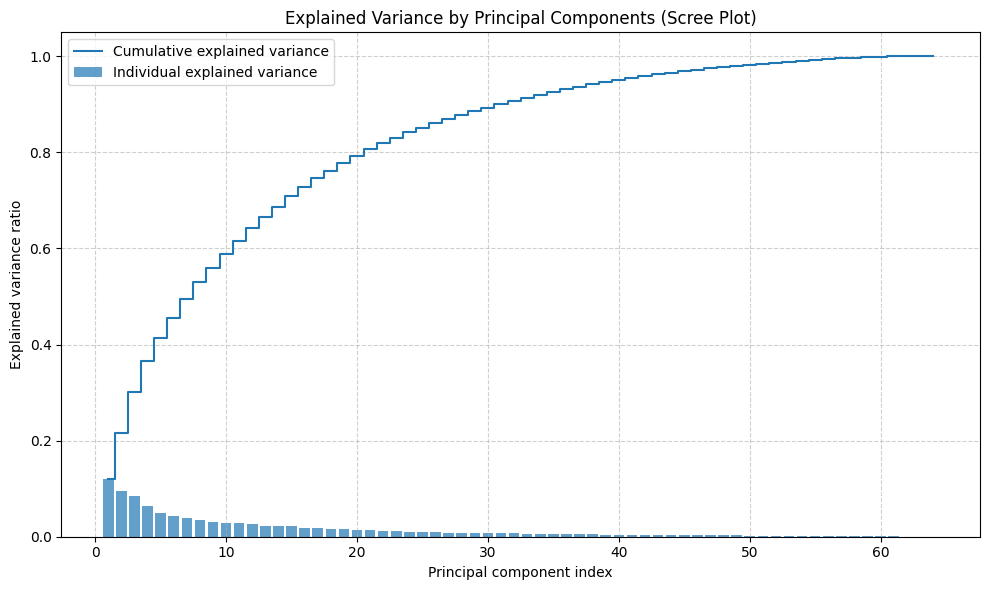

In [ ]:
# --- 3. Apply PCA ---

# First, let's determine the optimal number of components by checking the explained variance
pca_full = PCA()
pca_full.fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)


In [ ]:
# --- 5. Fit a Predictive Model ---
# Using Random Forest Classifier as suggested
print("Step 4: Fitting the Random Forest model...")
# Using n_estimators=100 for a more robust model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_pca, y_train)
print("Model training complete.\n")



Step 3: Reducing dimensions to 2 for visualization...
Shape of data after reduction to 2 dimensions: (1797, 2)



Step 4: Visualizing the 2D projection...


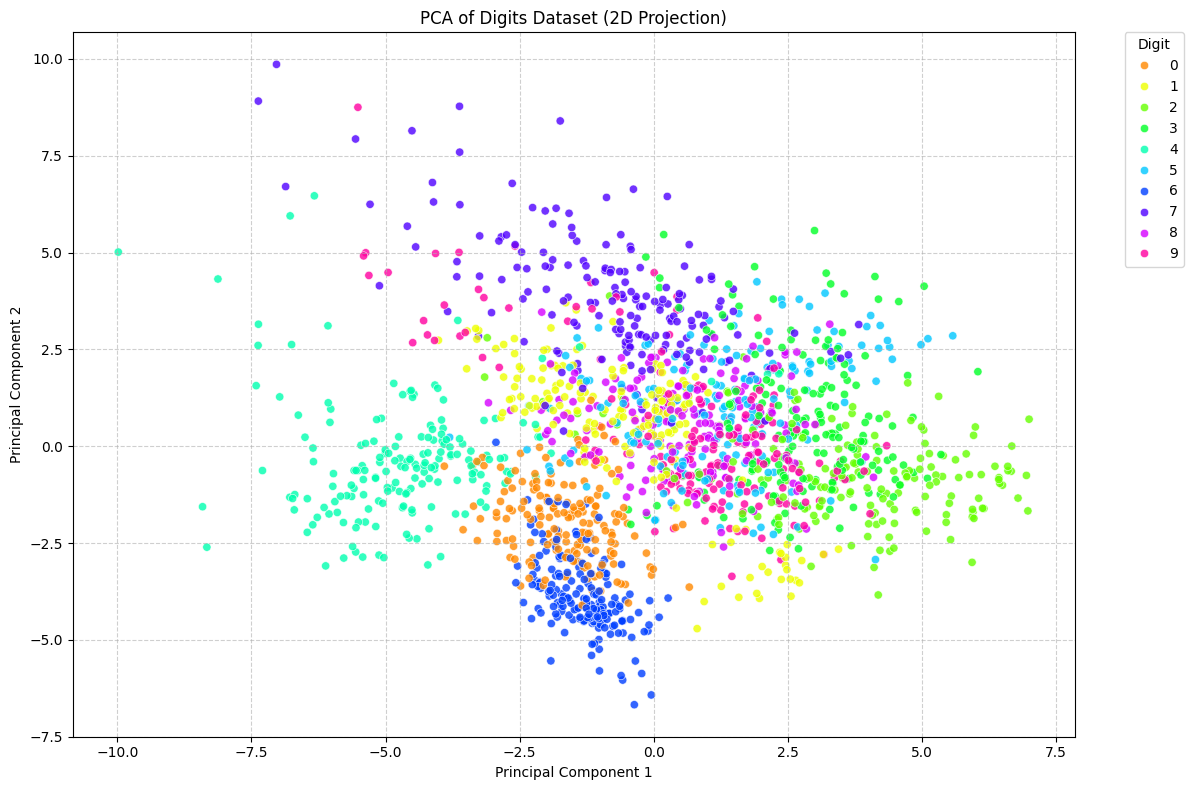

In [ ]:
# --- 6. Test Accuracy ---
print("Step 5: Predicting and testing accuracy...")
y_pred = model.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy (on PCA-reduced data): {accuracy:.4f}\n")


In [ ]:
print("Step 6: Visualizing the confusion matrix...")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
